<a href="https://colab.research.google.com/github/Thulasi604/ML-PROJECT/blob/main/ThulasiP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [223]:
import pandas as pd
import numpy as np


In [224]:
df=pd.read_csv('/content/the_loan.csv')

In [225]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [227]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [228]:
df.shape

(614, 13)

In [229]:
df.size

7982

In [230]:
df.isna().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [231]:
df=df.drop(columns=['Loan_ID','Gender'])

In [232]:

df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [233]:
df.isna().sum()

,0
Married,3
Dependents,15
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Property_Area,0


In [234]:
df=df.dropna(subset=['Married'])

In [235]:
df.isna().sum()

,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14
Credit_History,50
Property_Area,0


In [236]:
df['Dependents'].nunique()

4

In [237]:
cols=['LoanAmount','Credit_History','Loan_Amount_Term']
df[cols]=df[cols].fillna(df[cols].mean())

In [238]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

In [239]:
df.isna().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


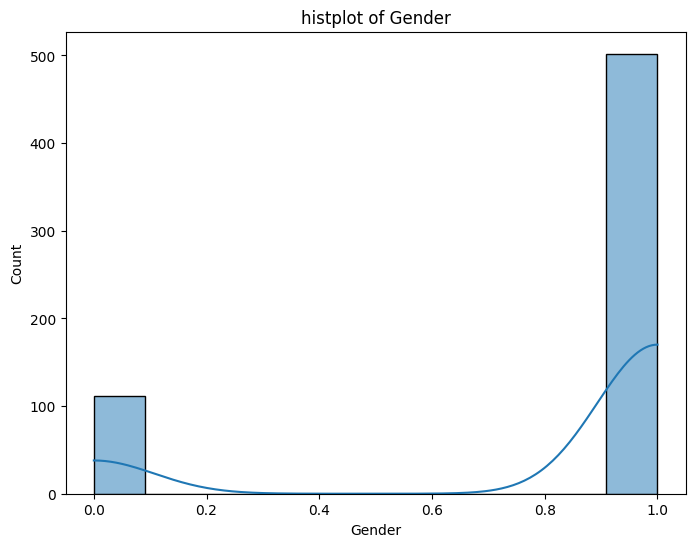

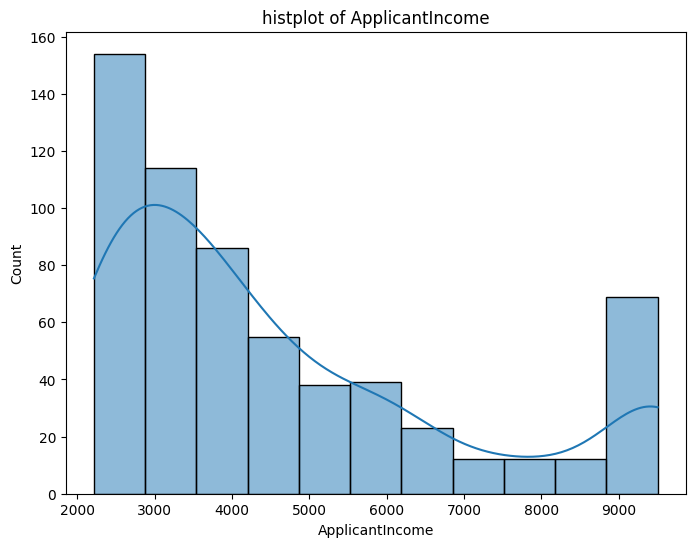

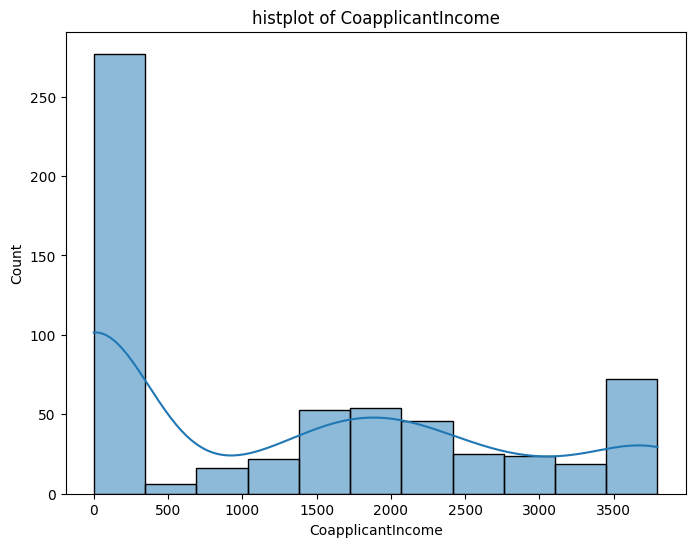

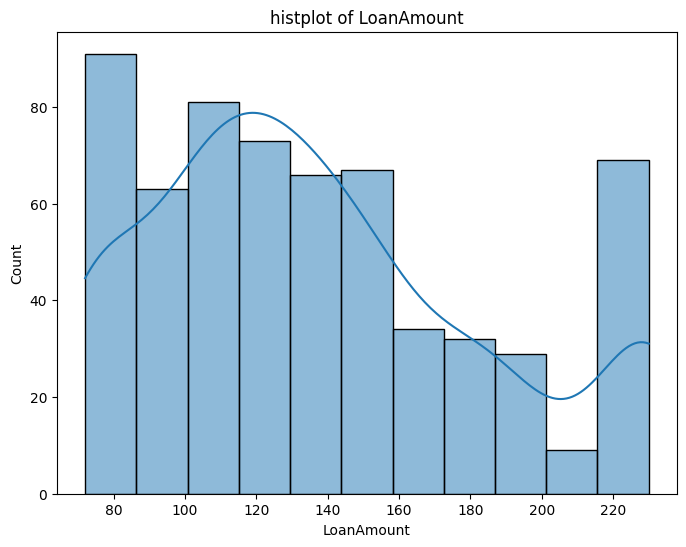

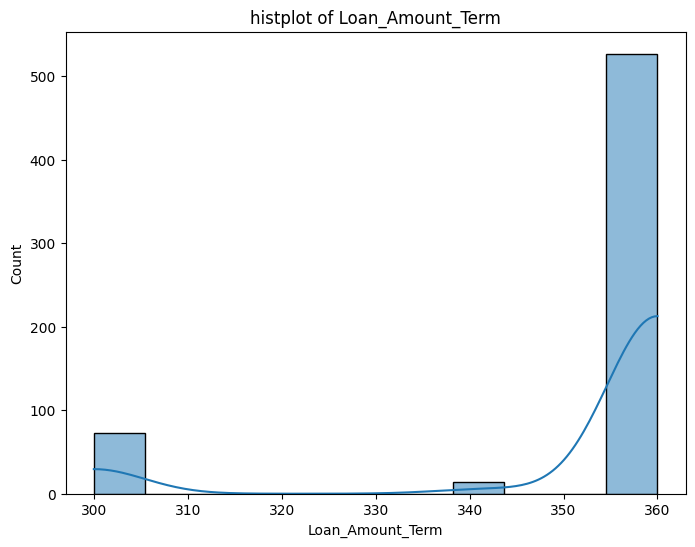

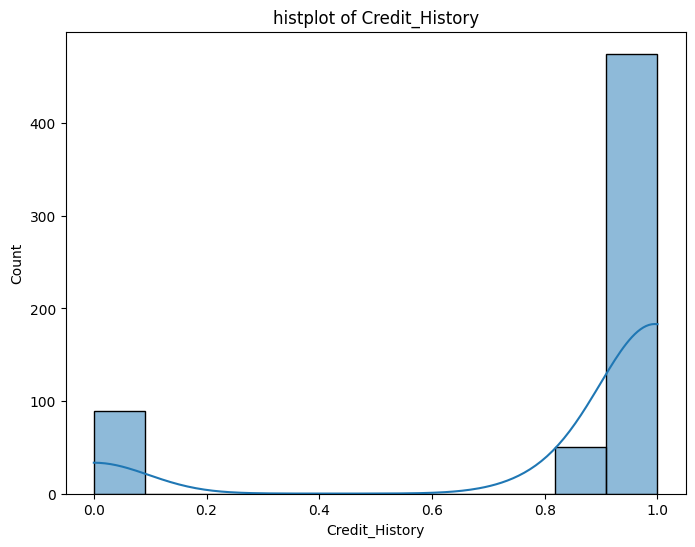

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
numerical_cols=loan.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.histplot(loan[col],kde=True)
  plt.title(f'histplot of {col}')
  plt.show()

In [241]:
from scipy.stats import skew
cat_values=df.select_dtypes(include='object').columns
num_value=df.select_dtypes(include=['int64','float64']).columns
skew_value=df[num_value].skew()
skew_value

,0
ApplicantIncome,6.535346
CoapplicantIncome,7.479901
LoanAmount,2.721780
Loan_Amount_Term,-2.431957
Credit_History,-1.954970


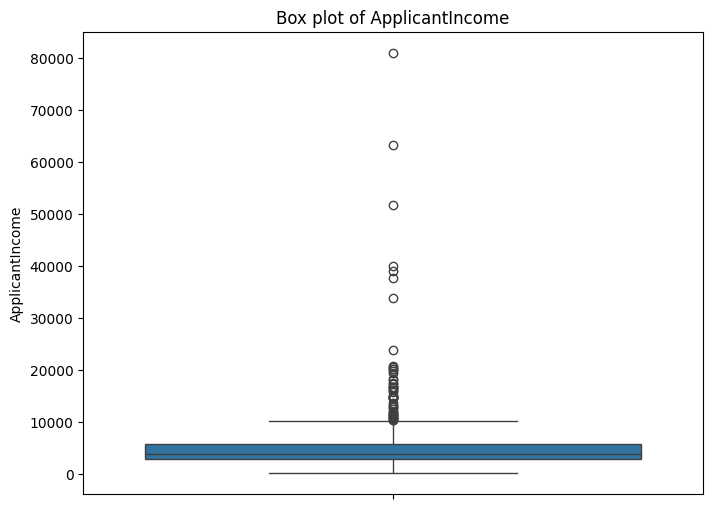

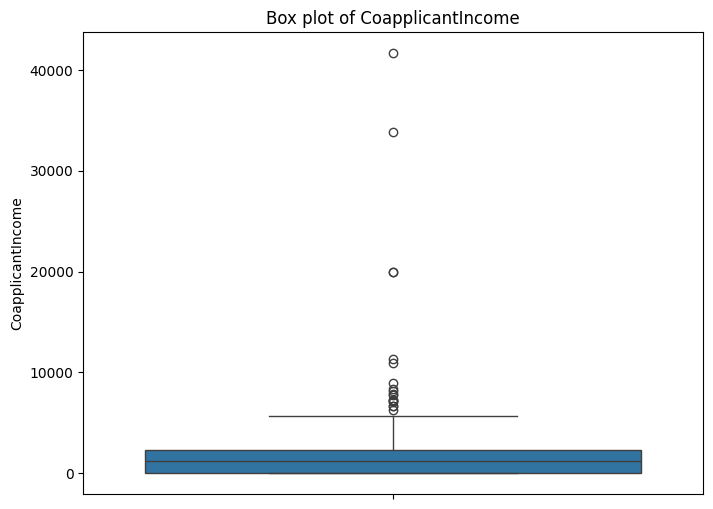

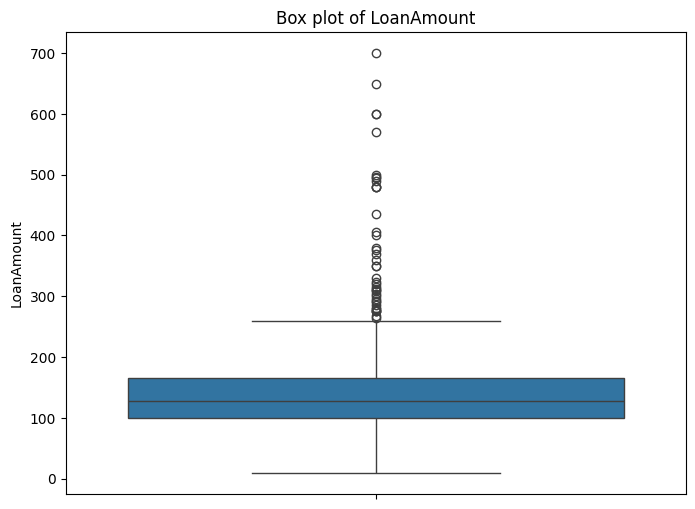

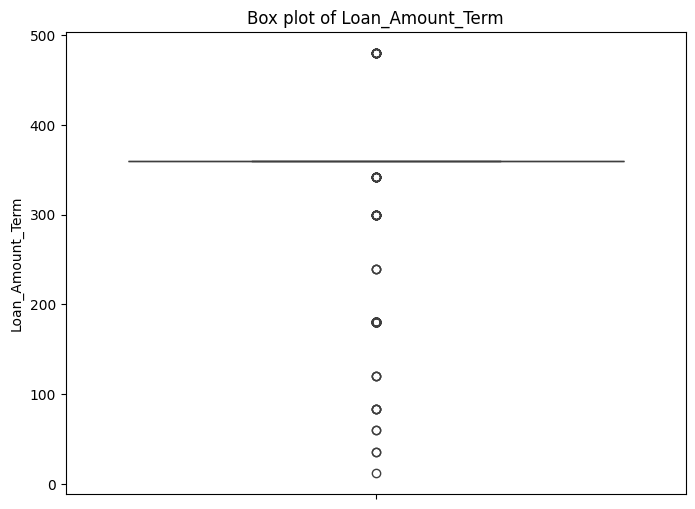

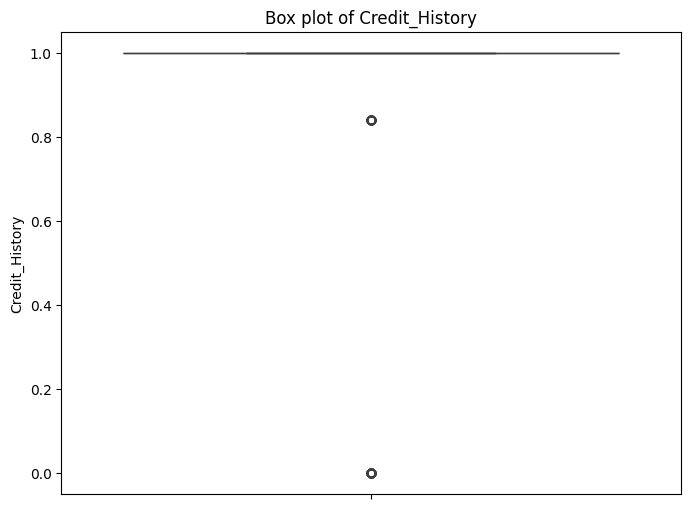

In [242]:

import numpy as np
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f'Box plot of {col}')
  plt.show()

In [243]:
from scipy.stats.mstats import winsorize
for col in ['ApplicantIncome','CoapplicantIncome','Credit_History','LoanAmount','Loan_Amount_Term']:
  df[col]=winsorize(df[col],(0.1,0.1))


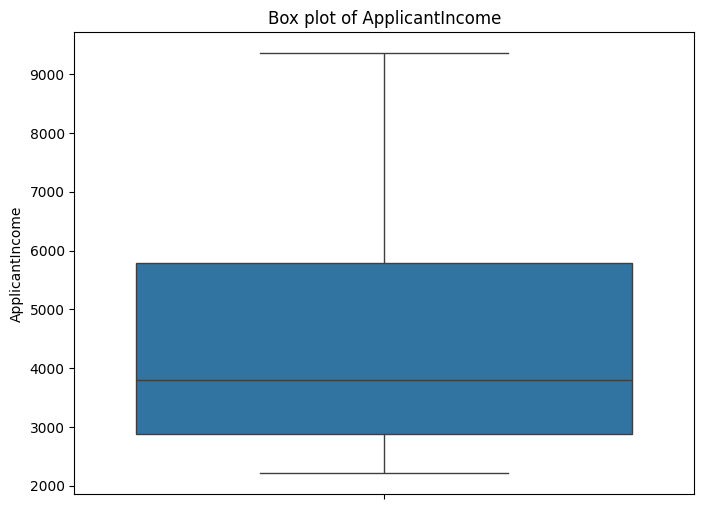

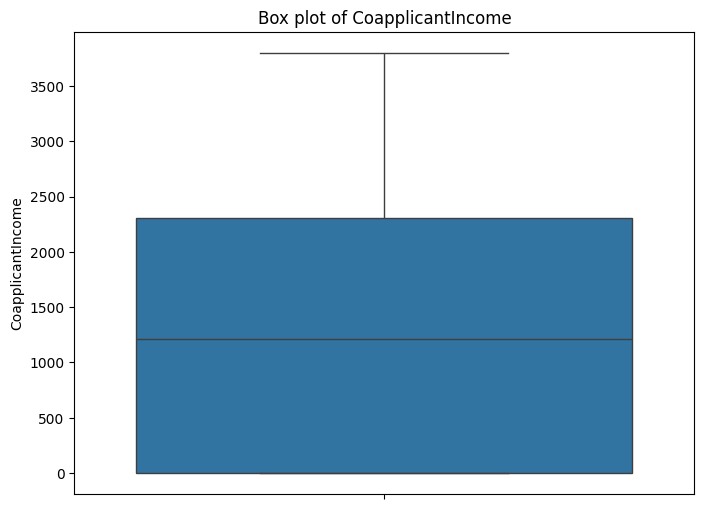

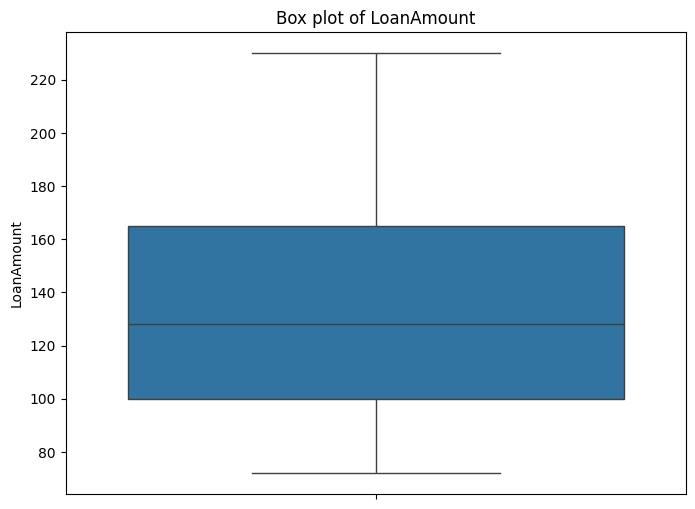

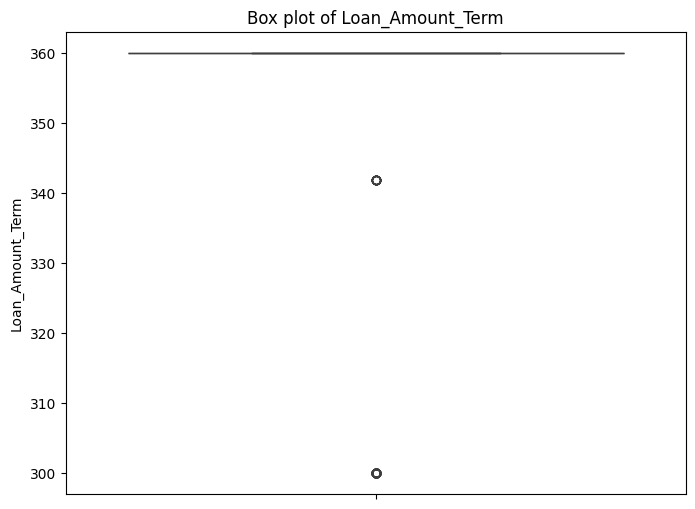

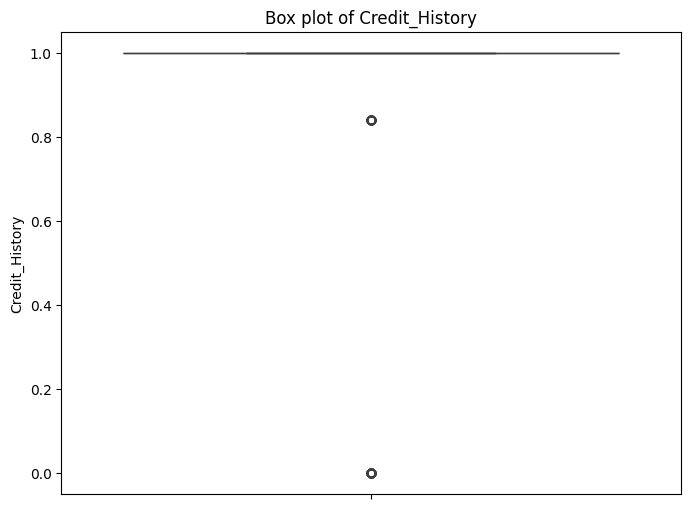

In [244]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f'Box plot of {col}')
  plt.show()

In [245]:
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,No,0,Graduate,No,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Yes,0,Graduate,Yes,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...
609,No,0,Graduate,No,2900,0.0,72.000000,360.0,1.0,Rural,Y
610,Yes,3+,Graduate,No,4106,0.0,72.000000,300.0,1.0,Rural,Y
611,Yes,1,Graduate,No,8072,240.0,230.000000,360.0,1.0,Urban,Y
612,Yes,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [246]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Married']=le.fit_transform(df['Married'])
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,Graduate,No,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,1,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,1,0,Graduate,Yes,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,1,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,0,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,Graduate,No,2900,0.0,72.000000,360.0,1.0,Rural,Y
610,1,3+,Graduate,No,4106,0.0,72.000000,300.0,1.0,Rural,Y
611,1,1,Graduate,No,8072,240.0,230.000000,360.0,1.0,Urban,Y
612,1,2,Graduate,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [247]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
oe=OrdinalEncoder()
df['Education']=le.fit_transform(df['Education'])
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,No,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,1,1,0,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,1,0,0,Yes,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,1,0,1,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,0,0,0,No,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,No,2900,0.0,72.000000,360.0,1.0,Rural,Y
610,1,3+,0,No,4106,0.0,72.000000,300.0,1.0,Rural,Y
611,1,1,0,No,8072,240.0,230.000000,360.0,1.0,Urban,Y
612,1,2,0,No,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [248]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Self_Employed']=le.fit_transform(df['Self_Employed'])
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,0,5849,0.0,146.369492,360.0,1.0,Urban,Y
1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,1,0,0,1,3000,0.0,72.000000,360.0,1.0,Urban,Y
3,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,0,0,0,0,6000,0.0,141.000000,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,2900,0.0,72.000000,360.0,1.0,Rural,Y
610,1,3+,0,0,4106,0.0,72.000000,300.0,1.0,Rural,Y
611,1,1,0,0,8072,240.0,230.000000,360.0,1.0,Urban,Y
612,1,2,0,0,7583,0.0,187.000000,360.0,1.0,Urban,Y


In [249]:
df=pd.get_dummies(df,columns=['Property_Area'],prefix='Property',drop_first=True)
df.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Semiurban,Property_Urban
0,0,0,0,0,5849,0.0,146.369492,360.0,1.0,Y,False,True
1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,N,False,False
2,1,0,0,1,3000,0.0,72.000000,360.0,1.0,Y,False,True
3,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,Y,False,True
4,0,0,0,0,6000,0.0,141.000000,360.0,1.0,Y,False,True


In [250]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Loan_Status']=le.fit_transform(df['Loan_Status'])
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Semiurban,Property_Urban
0,0,0,0,0,5849,0.0,146.369492,360.0,1.0,1,False,True
1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,False,False
2,1,0,0,1,3000,0.0,72.000000,360.0,1.0,1,False,True
3,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,1,False,True
4,0,0,0,0,6000,0.0,141.000000,360.0,1.0,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,2900,0.0,72.000000,360.0,1.0,1,False,False
610,1,3+,0,0,4106,0.0,72.000000,300.0,1.0,1,False,False
611,1,1,0,0,8072,240.0,230.000000,360.0,1.0,1,False,True
612,1,2,0,0,7583,0.0,187.000000,360.0,1.0,1,False,True


In [251]:
bol_cols=df.select_dtypes(include='bool').columns
df[bol_cols]=df[bol_cols].astype(int)

In [252]:
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Semiurban,Property_Urban
0,0,0,0,0,5849,0.0,146.369492,360.0,1.0,1,0,1
1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0,0
2,1,0,0,1,3000,0.0,72.000000,360.0,1.0,1,0,1
3,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,1,0,1
4,0,0,0,0,6000,0.0,141.000000,360.0,1.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,2900,0.0,72.000000,360.0,1.0,1,0,0
610,1,3+,0,0,4106,0.0,72.000000,300.0,1.0,1,0,0
611,1,1,0,0,8072,240.0,230.000000,360.0,1.0,1,0,1
612,1,2,0,0,7583,0.0,187.000000,360.0,1.0,1,0,1


In [253]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [254]:
y=df['Loan_Status']
x=df.drop(['Loan_Status'],axis=1)

In [255]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

In [256]:
x_train.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Semiurban,Property_Urban
88,0,0,0,0,8566,0.0,210.0,360.0,1.000000,0,1
515,1,3,0,0,3466,3428.0,150.0,360.0,1.000000,0,0
118,1,0,0,0,5568,2142.0,175.0,360.0,1.000000,0,0
395,1,2,0,0,3276,484.0,135.0,360.0,0.841355,1,0
419,1,0,0,0,3246,1417.0,138.0,360.0,1.000000,1,0


In [257]:
y=df['Loan_Status']
x=df.drop(['Loan_Status'],axis=1)

In [258]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
x_train=std_scaler.fit_transform(x_train)

In [259]:
x_test=std_scaler.transform(x_test)

In [260]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()

In [261]:
lr_model.fit(x_train,y_train)

LogisticRegression()

In [262]:
y_predict=lr_model.predict(x_test)
y_predict

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [263]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
confusion_matrix(y_test,y_predict)

array([[ 19,  27],
       [  4, 103]])

In [264]:
accuracy=accuracy_score(y_test,y_predict)
accuracy


0.7973856209150327

In [265]:
from sklearn.neighbors import KNeighborsClassifier

In [266]:
metric_k={}

neighbors=np.arange(3,20)
for k in neighbors:
  knn_model=KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2)
  knn_model.fit(x_train,y_train)
  y_predict=knn_model.predict(x_test)
  acc=accuracy_score(y_test,y_predict)
  metric_k[k]=acc
metric_k

{np.int64(3): 0.738562091503268,
 np.int64(4): 0.7647058823529411,
 np.int64(5): 0.7973856209150327,
 np.int64(6): 0.7777777777777778,
 np.int64(7): 0.7973856209150327,
 np.int64(8): 0.7843137254901961,
 np.int64(9): 0.7843137254901961,
 np.int64(10): 0.7908496732026143,
 np.int64(11): 0.803921568627451,
 np.int64(12): 0.7973856209150327,
 np.int64(13): 0.8104575163398693,
 np.int64(14): 0.8169934640522876,
 np.int64(15): 0.8104575163398693,
 np.int64(16): 0.803921568627451,
 np.int64(17): 0.7973856209150327,
 np.int64(18): 0.803921568627451,
 np.int64(19): 0.7908496732026143}

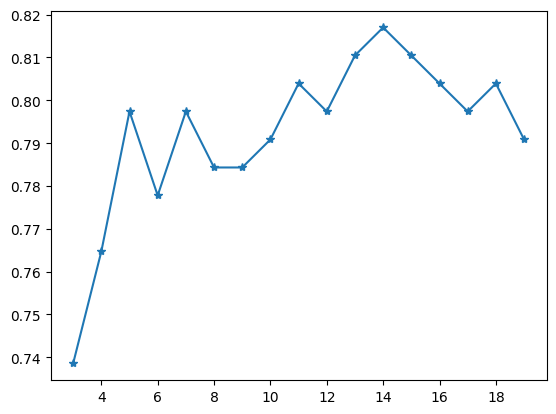

In [267]:
plt.plot(metric_k.keys(),metric_k.values(),marker="*")

In [268]:
knn_model=KNeighborsClassifier(n_neighbors=10)
knn_model.fit(x_train,y_train)
y_predict=knn_model.predict(x_test)
accuracy_score(y_test,y_predict)

0.7908496732026143

In [269]:
confusion_matrix(y_test,y_predict)

array([[ 20,  26],
       [  6, 101]])

In [270]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(criterion='gini',max_depth=5,min_samples_split=10,random_state=42,min_samples_leaf=10)
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.7581699346405228


array([[20, 26],
       [11, 96]])

In [271]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=20,max_depth=10,
                                min_samples_split=3)
rf_model.fit(x_train,y_train)
y_predict=rf_model.predict(x_test)
print(accuracy_score(y_test,y_predict))
confusion_matrix(y_test,y_predict)

0.7973856209150327


array([[ 20,  26],
       [  5, 102]])

In [272]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train)
y_predict=nb_model.predict(x_test)
print(accuracy_score(y_test,y_predict))
confusion_matrix(y_test,y_predict)

0.8104575163398693


array([[ 19,  27],
       [  2, 105]])

In [273]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_dist = {
    'n_estimators': np.arange(10, 200, 10),
    'max_features': ['sqrt', 'log2', None],
    'max_depth': np.arange(1, 20, 1),
    'min_samples_split': np.arange(2, 20, 1),
    'min_samples_leaf': np.arange(1, 10, 1),
    'criterion': ['gini', 'entropy']
}


rf_model_ht = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(estimator=rf_model_ht,
                                   param_distributions=param_dist,
                                   n_iter=50,
                                   cv=5,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(x_train, y_train)


print("Best parameters found: ", random_search.best_params_)
print("Best accuracy found: ", random_search.best_score_)


best_rf_model = random_search.best_estimator_
y_pred_ht = best_rf_model.predict(x_test)


from sklearn.metrics import accuracy_score, confusion_matrix
print("\nAccuracy of the best Random Forest model after tuning:", accuracy_score(y_test, y_pred_ht))
print("Confusion Matrix of the best Random Forest model after tuning:\n", confusion_matrix(y_test, y_pred_ht))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'n_estimators': np.int64(10), 'min_samples_split': np.int64(17), 'min_samples_leaf': np.int64(8), 'max_features': 'log2', 'max_depth': np.int64(17), 'criterion': 'entropy'}
Best accuracy found:  0.8078595317725752

Accuracy of the best Random Forest model after tuning: 0.8104575163398693
Confusion Matrix of the best Random Forest model after tuning:
 [[ 19  27]
 [  2 105]]


In [274]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

nb_model_ht = GaussianNB()


random_search_nb = RandomizedSearchCV(estimator=nb_model_ht,
                                    param_distributions=param_dist_nb,
                                    n_iter=50,
                                    cv=5,
                                    verbose=2,
                                    random_state=42,
                                    n_jobs=-1)

random_search_nb.fit(x_train, y_train)


print("\nBest parameters found for GaussianNB: ", random_search_nb.best_params_)
print("Best accuracy found for GaussianNB: ", random_search_nb.best_score_)


best_nb_model = random_search_nb.best_estimator_
y_pred_nb_ht = best_nb_model.predict(x_test)


from sklearn.metrics import accuracy_score, confusion_matrix
print("\nAccuracy of the best GaussianNB model after tuning:", accuracy_score(y_test, y_pred_nb_ht))
print("Confusion Matrix of the best GaussianNB model after tuning:\n", confusion_matrix(y_test, y_pred_nb_ht))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found for GaussianNB:  {'var_smoothing': np.float64(0.12328467394420659)}
Best accuracy found for GaussianNB:  0.8078356426182512

Accuracy of the best GaussianNB model after tuning: 0.8104575163398693
Confusion Matrix of the best GaussianNB model after tuning:
 [[ 19  27]
 [  2 105]]


In [275]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [276]:
model=Sequential()
model.add(Input(shape=(11,)))
#Adding Hidden layers
model.add(Dense(10,activation='relu'))
model.add(Dense(2,activation='softmax'))

In [277]:
from sklearn.utils import validation
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']) #Loss fn(multiple :Categorical cross entropy)

#Data
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test)) #100 iteration

loss,accuracy=model.evaluate(x_test,y_test)

print("test accuracy",accuracy)


Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6453 - loss: 0.6591 - val_accuracy: 0.6471 - val_loss: 0.6374
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7128 - loss: 0.5983 - val_accuracy: 0.6732 - val_loss: 0.6186
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6967 - loss: 0.6121 - val_accuracy: 0.6797 - val_loss: 0.6071
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7286 - loss: 0.5610 - val_accuracy: 0.6667 - val_loss: 0.5993
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7250 - loss: 0.5584 - val_accuracy: 0.6732 - val_loss: 0.5927
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7507 - loss: 0.5118 - val_accuracy: 0.6797 - val_loss: 0.5877
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7996 - loss: 0.4836 - val_accuracy: 0.7190 - val_loss: 0.5815
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7387 - loss: 0.5354 - val_accuracy: 0.7190 - v

In [278]:
prediction=model.predict(x_test)
predicted_class=np.argmax(prediction,axis=1)
predicted_class

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


array([1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [279]:
new_data=np.array([[5.1,3.5,1.4,0.2,0.5,0.6,0.7,0.8,0.9,1.0,1.1],
                   [6.0,2.7,4.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0]])
new_data=std_scaler.transform(new_data)
prediction=model.predict(new_data)
predicted_class=np.argmax(prediction,axis=1)
predicted_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1, 1])

In [280]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.68 KB)

 Trainable params: 142 (568.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 286 (1.12 KB)